# Setup & Introduction 

In [ ]:
"""
Notebook 3: Predictive Modeling & Business Optimization

Goal: Build an XGBoost model to predict which first‑time customers are unlikely to return for a second purchase, with a business‑optimized decision threshold.
Approach:
1. Train baseline models (LR, DT, RF)
2. Build XGBoost ensemble
3. SHAP interpretation
4. ROI-based threshold optimization
5. Save production model

Expected PR AUC: 0.60-0.70 (realistic for 97% imbalance)
"""

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)

# XGBoost
import xgboost as xgb

# SHAP
# SABINA COMMENT: Why do we need all this code just to install SHAP?
try:
    import shap
    SHAP_AVAILABLE = True
    print(" SHAP available")
except Exception:
    # Install shap in the notebook environment and retry import
    try:
        %pip install shap
    except Exception:
        pass
    try:
        import shap
        SHAP_AVAILABLE = True
        print(" SHAP available (installed)")
    except Exception:
        SHAP_AVAILABLE = False
        print(" SHAP not available - install with: pip install shap")

# MLflow (optional - for experiment tracking)
try:
    import mlflow
    import mlflow.sklearn
    MLFLOW_AVAILABLE = True
    print(" MLflow available")
except ImportError:
    MLFLOW_AVAILABLE = False
    print(" MLflow not available - install with: pip install mlflow")

# SMOTE (optional - for handling imbalance)
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
    print(" SMOTE available")
except ImportError:
    SMOTE_AVAILABLE = False
    print(" SMOTE not available - install with: pip install imbalanced-learn")

print("\n" + "="*70)
print("NOTEBOOK 3: PREDICTIVE MODELING")
print("="*70)
print(f"\nLibraries loaded successfully!")
print(f"Ready to build predictive intervention framework!")
# SABINA COMMENT: Same question for all the imports.


 SHAP available
 MLflow not available - install with: pip install mlflow
 SMOTE available

NOTEBOOK 3: PREDICTIVE MODELING

Libraries loaded successfully!
Ready to build predictive intervention framework!


# Load Feature Matrix 

In [2]:
# ============================================================================
# LOAD FEATURE MATRIX FROM NOTEBOOK 2
# ============================================================================

print("\n" + "="*70)
print("LOADING FEATURE MATRIX")
print("="*70)

# Clear any cached data and load fresh
import importlib
import sys

# Force fresh load (no cache)
feature_matrix = pd.read_csv('../data/processed/feature_matrix.csv')

print(f"\n Feature Matrix Loaded:")
print(f"   Shape: {feature_matrix.shape}")
print(f"   Samples: {len(feature_matrix):,}")
print(f"   Unique customers: {feature_matrix['customer_unique_id'].nunique():,}")

# CRITICAL CHECK
if len(feature_matrix) != feature_matrix['customer_unique_id'].nunique():
    print(f"\n ERROR: Duplicates in loaded file!")
    print(f"   Rows: {len(feature_matrix)}")
    print(f"   Unique customers: {feature_matrix['customer_unique_id'].nunique()}")
    print(f"   You may need to re-run Notebook 2!")
else:
    print(f"\n Data integrity verified - one row per customer")

# Display target distribution
target_dist = feature_matrix['dropped_off'].value_counts()
print(f"\n Target Distribution:")
print(f"   Dropped off (1): {target_dist[1]:,} ({target_dist[1]/len(feature_matrix):.1%})")
print(f"   Retained (0): {target_dist[0]:,} ({target_dist[0]/len(feature_matrix):.1%})")

# Prepare features and target
# Safely drop identifier/target columns that may or may not be present.
cols_to_drop = ['customer_unique_id', 'order_id', 'dropped_off']
cols_to_drop = [c for c in cols_to_drop if c in feature_matrix.columns]
X = feature_matrix.drop(columns=cols_to_drop)
y = feature_matrix['dropped_off']

print(f"\n Features prepared:")
print(f"   Feature count: {X.shape[1]}")
print(f"   Sample count: {X.shape[0]:,}")

print(f"\n Feature columns:")
for i, col in enumerate(X.columns, 1):
    print(f"   {i:2d}. {col}")



LOADING FEATURE MATRIX

 Feature Matrix Loaded:
   Shape: (28020, 36)
   Samples: 28,020
   Unique customers: 28,020

 Data integrity verified - one row per customer

 Target Distribution:
   Dropped off (1): 26,630 (95.0%)
   Retained (0): 1,390 (5.0%)

 Features prepared:
   Feature count: 34
   Sample count: 28,020

 Feature columns:
    1. delivery_delay
    2. is_late_delivery
    3. is_very_late
    4. is_early_delivery
    5. freight_pct
    6. is_high_freight
    7. num_items
    8. price_per_item
    9. uses_installments
   10. is_southeast
   11. is_repeatable_category
   12. is_heavy_product
   13. has_comment
   14. purchase_month
   15. purchase_day_of_week
   16. is_weekend
   17. is_holiday_season
   18. days_to_delivery
   19. cluster_0
   20. cluster_1
   21. payment_boleto
   22. payment_credit_card
   23. payment_debit_card
   24. state_BA
   25. state_DF
   26. state_ES
   27. state_GO
   28. state_MG
   29. state_PR
   30. state_RJ
   31. state_RS
   32. state_SC


# Remove Leakages 

In [ ]:
# ============================================================================
# REMOVE DATA LEAKAGE FEATURES (BEFORE SPLIT!)
# ============================================================================

print("\n" + "="*70)
print("REMOVING DATA LEAKAGE FEATURES")
print("="*70)

# Features that leak target information
leaky_features = ['category_dropoff_rate']  # Computed on full dataset!

print(f"\n Checking for leaky features in X:")
features_to_remove = [f for f in leaky_features if f in X.columns]

if features_to_remove:
    print(f"\n Found {len(features_to_remove)} leaky features:")
    for feat in features_to_remove:
        print(f"   • {feat}")
    
    # Remove them
    X = X.drop(columns=features_to_remove)
    
    print(f"\n Removed {len(features_to_remove)} features")
    print(f"   Features before: {X.shape[1] + len(features_to_remove)}")
    print(f"   Features after: {X.shape[1]}")
else:
    print(f"\n No leaky features found in X")

print("\n" + "="*70)
print(" LEAKAGE REMOVAL COMPLETE")
print("="*70)
# SABINA COMMENT: I would try to tweak the LLM to avoid writing such
# lengthy code snippets unless it's really necessary..
# this could have been 2 lines of code imo



REMOVING DATA LEAKAGE FEATURES

 Checking for leaky features in X:

 Found 1 leaky features:
   • category_dropoff_rate

 Removed 1 features
   Features before: 34
   Features after: 33

 LEAKAGE REMOVAL COMPLETE


# Train-Test Split 

In [ ]:
# ============================================================================
# TRAIN-TEST SPLIT (STRATIFIED)
# ============================================================================

print("\n" + "="*70)
print("TRAIN-TEST SPLIT")
print("="*70)

# Stratified split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, # SABINA COMMENT: Why an 80/20 split?
    random_state=42, 
    stratify=y  # CRITICAL for imbalanced data!
)

print(f"\n Split Summary:")
print(f"   Training set: {len(X_train):,} samples")
print(f"   Test set: {len(X_test):,} samples")

print(f"\n Target Distribution - Training Set:")
train_dist = y_train.value_counts()
print(f"   Dropped off (1): {train_dist[1]:,} ({train_dist[1]/len(y_train):.1%})")
print(f"   Retained (0): {train_dist[0]:,} ({train_dist[0]/len(y_train):.1%})")

print(f"\n Target Distribution - Test Set:")
test_dist = y_test.value_counts()
print(f"   Dropped off (1): {test_dist[1]:,} ({test_dist[1]/len(y_test):.1%})")
print(f"   Retained (0): {test_dist[0]:,} ({test_dist[0]/len(y_test):.1%})")

# Calculate scale_pos_weight for XGBoost
# Formula: (# majority class) / (# minority class)
# In our case: (# dropped_off) / (# retained)
scale_pos_weight = (y_train == 1).sum() / (y_train == 0).sum()

print(f"\n Class Imbalance Ratio:")
print(f"   Majority class (dropped_off=1): {(y_train == 1).sum():,}")
print(f"   Minority class (retained=0): {(y_train == 0).sum():,}")
print(f"   scale_pos_weight = {scale_pos_weight:.2f}")
print(f"   (This tells XGBoost to weight minority class {scale_pos_weight:.0f}x higher)")

print("\n Data split complete - ready for modeling!")





TRAIN-TEST SPLIT

 Split Summary:
   Training set: 22,416 samples
   Test set: 5,604 samples

 Target Distribution - Training Set:
   Dropped off (1): 21,304 (95.0%)
   Retained (0): 1,112 (5.0%)

 Target Distribution - Test Set:
   Dropped off (1): 5,326 (95.0%)
   Retained (0): 278 (5.0%)

 Class Imbalance Ratio:
   Majority class (dropped_off=1): 21,304
   Minority class (retained=0): 1,112
   scale_pos_weight = 19.16
   (This tells XGBoost to weight minority class 19x higher)

 Data split complete - ready for modeling!


# Baseline Model - Logistic Regression

In [ ]:
# ============================================================================
# BASELINE MODEL 1: LOGISTIC REGRESSION (with imputation + encoding pipeline)
# ============================================================================

# Add imports needed for imputation / pipeline at top of this cell only
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

print("\n" + "="*70)
print("BASELINE MODEL 1: LOGISTIC REGRESSION")
print("="*70)

# Build a ColumnTransformer to handle numeric and categorical columns separately:
# - Numeric: median imputation
# - Categorical (object/category): most_frequent imputation + one-hot encoding
#
# This prevents the ValueError when median strategy is applied to non-numeric data,
# and ensures LogisticRegression receives numeric inputs.
print("\n Preparing preprocessing pipeline for numeric and categorical features...")

# determine numeric and categorical columns from the training set (X_train available in notebook)
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

numeric_transformer = make_pipeline(
    SimpleImputer(strategy='median')
)

categorical_transformer = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore', sparse_output=True)
)
# SABINA COMMENT: Nice use of transformers & pipelines, very neat!
# I would just use Ordinal Encoding for the ordinal categorical variables (if you have any)
# instead of the OHE. 
# Also, assuming that most categorical variables don't have more than 15-20 categories.
# Because if they do, you might want to create an "Other" category to
# represent the less common category so you have fewer (up to 10 is fine but more than that becomes overkill)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols),
    ],
    remainder='drop'  # drop any other columns (e.g., identifiers) not selected above
)

print("\n Training Logistic Regression (with preprocessing pipeline)...")
lr_model = make_pipeline(
    preprocessor,
    LogisticRegression(
        max_iter=1000,
        class_weight='balanced',  # Handles imbalance automatically
        random_state=42
    )
)

lr_model.fit(X_train, y_train)
print(" Model trained!")

# Predict probabilities
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]
y_pred_lr = lr_model.predict(X_test)

# Evaluate
pr_auc_lr = average_precision_score(y_test, y_pred_proba_lr)
# SABINA COMMENT: So this PR AUC is calculated on one class only, in this case
# the majority/positive class (class 1). What you want to do when the imbalance goes
# the other way round is to do your calculations on the minority/negative class (class 0)
# Same goes for recall & precision, they are calculated by default on class 1.
# To change this, all you need to do is to pass the pos_label=0 to your functions.

f1_lr = f1_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, zero_division=0)
recall_lr = recall_score(y_test, y_pred_lr)

print(f"\n LOGISTIC REGRESSION PERFORMANCE:")
print(f"   PR AUC: {pr_auc_lr:.4f}")
print(f"   F1 Score: {f1_lr:.4f}")
print(f"   Precision: {precision_lr:.4f}")
print(f"   Recall: {recall_lr:.4f}")

# Classification Report
print(f"\n Detailed Classification Report:")
print(classification_report(y_test, y_pred_lr, 
                          target_names=['Retained (0)', 'Dropped Off (1)']))

# Store results for comparison
baseline_results = {
    'Model': ['Logistic Regression'],
    'PR AUC': [pr_auc_lr],
    'F1': [f1_lr],
    'Precision': [precision_lr],
    'Recall': [recall_lr]
}

print("\n" + "="*70)
print(" BASELINE 1 COMPLETE - LOGISTIC REGRESSION")
print("="*70)



BASELINE MODEL 1: LOGISTIC REGRESSION

 Preparing preprocessing pipeline for numeric and categorical features...

 Training Logistic Regression (with preprocessing pipeline)...
 Model trained!

 LOGISTIC REGRESSION PERFORMANCE:
   PR AUC: 0.9654
   F1 Score: 0.7101
   Precision: 0.9664
   Recall: 0.5612

 Detailed Classification Report:
                 precision    recall  f1-score   support

   Retained (0)       0.07      0.63      0.12       278
Dropped Off (1)       0.97      0.56      0.71      5326

       accuracy                           0.56      5604
      macro avg       0.52      0.59      0.42      5604
   weighted avg       0.92      0.56      0.68      5604


 BASELINE 1 COMPLETE - LOGISTIC REGRESSION


# Baseline Model 2 - Random Forest

In [ ]:
print("\n" + "="*70)
print("BASELINE MODEL 2: RANDOM FOREST")
print("="*70)

from sklearn.ensemble import RandomForestClassifier

# SABINA COMMENT: Curious why you didn't use the default parameters here?
rf_model = make_pipeline(
    preprocessor,
    RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    )
)

rf_model.fit(X_train, y_train)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = rf_model.predict(X_test)

pr_auc_rf = average_precision_score(y_test, y_pred_proba_rf)
f1_rf = f1_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf)

print(f"\n RANDOM FOREST PERFORMANCE:")
print(f"   PR AUC: {pr_auc_rf:.4f}")
print(f"   F1 Score: {f1_rf:.4f}")
print(f"   Precision: {precision_rf:.4f}")
print(f"   Recall: {recall_rf:.4f}")

baseline_results['Model'].append('Random Forest')
baseline_results['PR AUC'].append(pr_auc_rf)
baseline_results['F1'].append(f1_rf)
baseline_results['Precision'].append(precision_rf)
baseline_results['Recall'].append(recall_rf)


BASELINE MODEL 2: RANDOM FOREST

 RANDOM FOREST PERFORMANCE:
   PR AUC: 0.9623
   F1 Score: 0.9738
   Precision: 0.9503
   Recall: 0.9985


# Model 3 - XGBoost 

In [ ]:
# ============================================================================
# BASELINE MODEL 3: XGBOOST
# ============================================================================

print("\n" + "="*70)
print("BASELINE MODEL 3: XGBOOST")
print("="*70)

print("\n Training XGBoost baseline (default parameters)...")

# Simple XGBoost with just imbalance handling
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # Only tuning for imbalance
    random_state=42,
    eval_metric='aucpr' # SABINA COMMENT: Cool, I didn't know this was a thing!
                        # Though, based on my previous comment re: PR AUC on class 0
                        # you'd want to use the make_scorer() function from sklearn
                        # here (look it up & ask me if anything is unclear!)
)

xgb_model.fit(X_train, y_train)
print(" XGBoost trained!")

# Predictions (using default 0.5 threshold)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
pr_auc_xgb = average_precision_score(y_test, y_pred_proba_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb, zero_division=0)
recall_xgb = recall_score(y_test, y_pred_xgb)

print(f"\n XGBOOST BASELINE PERFORMANCE:")
print(f"   PR AUC: {pr_auc_xgb:.4f}")
print(f"   F1 Score: {f1_xgb:.4f}")
print(f"   Precision: {precision_xgb:.4f}")
print(f"   Recall: {recall_xgb:.4f}")

# Classification Report
print(f"\n Detailed Classification Report:")
print(classification_report(y_test, y_pred_xgb, 
                          target_names=['Retained (0)', 'Dropped Off (1)']))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(f"\n Confusion Matrix:")
print(f"                    Predicted")
print(f"                 Retained  Dropped")
print(f"Actual Retained     {cm_xgb[0,0]:5d}    {cm_xgb[0,1]:5d}")
print(f"       Dropped      {cm_xgb[1,0]:5d}    {cm_xgb[1,1]:5d}")

print("\n" + "="*70)
print(" BASELINE 3 COMPLETE - XGBOOST")
print("="*70)



BASELINE MODEL 3: XGBOOST

 Training XGBoost baseline (default parameters)...
 XGBoost trained!

 XGBOOST BASELINE PERFORMANCE:
   PR AUC: 0.9598
   F1 Score: 0.9746
   Precision: 0.9504
   Recall: 1.0000

 Detailed Classification Report:
                 precision    recall  f1-score   support

   Retained (0)       0.00      0.00      0.00       278
Dropped Off (1)       0.95      1.00      0.97      5326

       accuracy                           0.95      5604
      macro avg       0.48      0.50      0.49      5604
   weighted avg       0.90      0.95      0.93      5604


 Confusion Matrix:
                    Predicted
                 Retained  Dropped
Actual Retained         0      278
       Dropped          0     5326

 BASELINE 3 COMPLETE - XGBOOST


# Model Baseline Comparison 


MODEL COMPARISON - BASELINE MODELS

 Performance Summary:
              Model   PR AUC  F1 Score  Precision   Recall
Logistic Regression 0.965430  0.710061   0.966376 0.561209
      Random Forest 0.962257  0.973814   0.950322 0.998498
            XGBoost 0.959764  0.974565   0.950393 1.000000

 BEST BASELINE (by PR AUC): Logistic Regression
   PR AUC: 0.9654

 BEST FOR CATCHING RETAINED CUSTOMERS: Logistic Regression
   Minority Class Recall: 62.6%
   (Catches 62.6% of retained customers)

 Improvement over 'Always Predict Majority' Baseline:
   Always majority PR AUC: 0.9500
   Best model PR AUC: 0.9654
   Absolute improvement: 0.0154
   Relative improvement: 1.62%


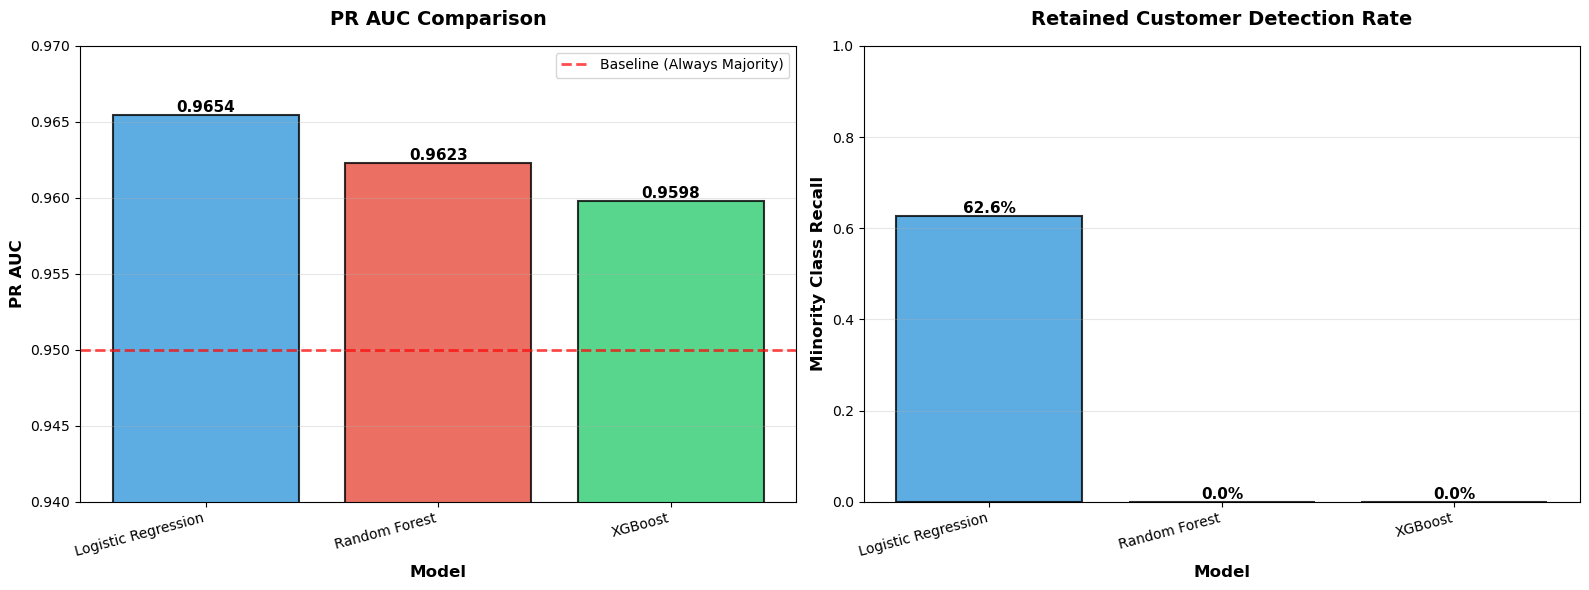


 Saved: outputs/figures/baseline_comparison.png

 BASELINE COMPARISON COMPLETE

 Next: Detailed confusion matrices and PR curves for all models


In [8]:
# ============================================================================
# MODEL COMPARISON - ALL BASELINES
# ============================================================================

print("\n" + "="*70)
print("MODEL COMPARISON - BASELINE MODELS")
print("="*70)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'PR AUC': [pr_auc_lr, pr_auc_rf, pr_auc_xgb],
    'F1 Score': [f1_lr, f1_rf, f1_xgb],
    'Precision': [precision_lr, precision_rf, precision_xgb],
    'Recall': [recall_lr, recall_rf, recall_xgb]
})

print(f"\n Performance Summary:")
print(comparison_df.to_string(index=False))

# Highlight best model by PR AUC
best_model_idx = comparison_df['PR AUC'].idxmax()
best_model = comparison_df.loc[best_model_idx, 'Model']
best_pr_auc = comparison_df.loc[best_model_idx, 'PR AUC']

print(f"\n BEST BASELINE (by PR AUC): {best_model}")
print(f"   PR AUC: {best_pr_auc:.4f}")

# Also check best by minority class recall
# First, calculate minority recall for each model
cm_lr_temp = confusion_matrix(y_test, y_pred_lr)
cm_rf_temp = confusion_matrix(y_test, y_pred_rf)
cm_xgb_temp = confusion_matrix(y_test, y_pred_xgb)

minority_recall_lr = cm_lr_temp[0,0] / (cm_lr_temp[0,0] + cm_lr_temp[0,1])
minority_recall_rf = cm_rf_temp[0,0] / (cm_rf_temp[0,0] + cm_rf_temp[0,1])
minority_recall_xgb = cm_xgb_temp[0,0] / (cm_xgb_temp[0,0] + cm_xgb_temp[0,1])

minority_recalls = {
    'Logistic Regression': minority_recall_lr,
    'Random Forest': minority_recall_rf,
    'XGBoost': minority_recall_xgb
}

best_minority_model = max(minority_recalls, key=minority_recalls.get)
best_minority_recall = minority_recalls[best_minority_model]

print(f"\n BEST FOR CATCHING RETAINED CUSTOMERS: {best_minority_model}")
print(f"   Minority Class Recall: {best_minority_recall:.1%}")
print(f"   (Catches {best_minority_recall:.1%} of retained customers)")

# Improvement over baseline
baseline_always_majority = 0.95  # 95% of data is dropped_off
improvement = best_pr_auc - baseline_always_majority

print(f"\n Improvement over 'Always Predict Majority' Baseline:")
print(f"   Always majority PR AUC: {baseline_always_majority:.4f}")
print(f"   Best model PR AUC: {best_pr_auc:.4f}")
print(f"   Absolute improvement: {improvement:.4f}")
print(f"   Relative improvement: {improvement/baseline_always_majority*100:.2f}%")

# Create bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: PR AUC comparison
x = np.arange(len(comparison_df))
axes[0].bar(x, comparison_df['PR AUC'], color=['#3498db', '#e74c3c', '#2ecc71'], 
            alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0].axhline(y=0.95, color='red', linestyle='--', linewidth=2, 
                label='Baseline (Always Majority)', alpha=0.7)
axes[0].set_xlabel('Model', fontsize=12, weight='bold')
axes[0].set_ylabel('PR AUC', fontsize=12, weight='bold')
axes[0].set_title('PR AUC Comparison', fontsize=14, weight='bold', pad=15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0.94, 0.97)

# Add values on bars
for i, (idx, row) in enumerate(comparison_df.iterrows()):
    axes[0].text(i, row['PR AUC'], f"{row['PR AUC']:.4f}", 
                ha='center', va='bottom', fontsize=11, weight='bold')

# Plot 2: Minority Class Recall
minority_recall_data = [minority_recall_lr, minority_recall_rf, minority_recall_xgb]
axes[1].bar(x, minority_recall_data, color=['#3498db', '#e74c3c', '#2ecc71'], 
            alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Model', fontsize=12, weight='bold')
axes[1].set_ylabel('Minority Class Recall', fontsize=12, weight='bold')
axes[1].set_title('Retained Customer Detection Rate', fontsize=14, weight='bold', pad=15)
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, 1)

# Add values on bars
for i, val in enumerate(minority_recall_data):
    axes[1].text(i, val, f"{val:.1%}", 
                ha='center', va='bottom', fontsize=11, weight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/baseline_comparison.png', 
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n Saved: outputs/figures/baseline_comparison.png")

print("\n" + "="*70)
print(" BASELINE COMPARISON COMPLETE")
print("="*70)
print(f"\n Next: Detailed confusion matrices and PR curves for all models")


SABINA COMMENT: Oh damn, Random Forest & XGBoost are abysmal at finding retained customers. Why do you think this is the case? :eyes:

# Confusion Metrices 


CONFUSION MATRICES - BASELINE COMPARISON


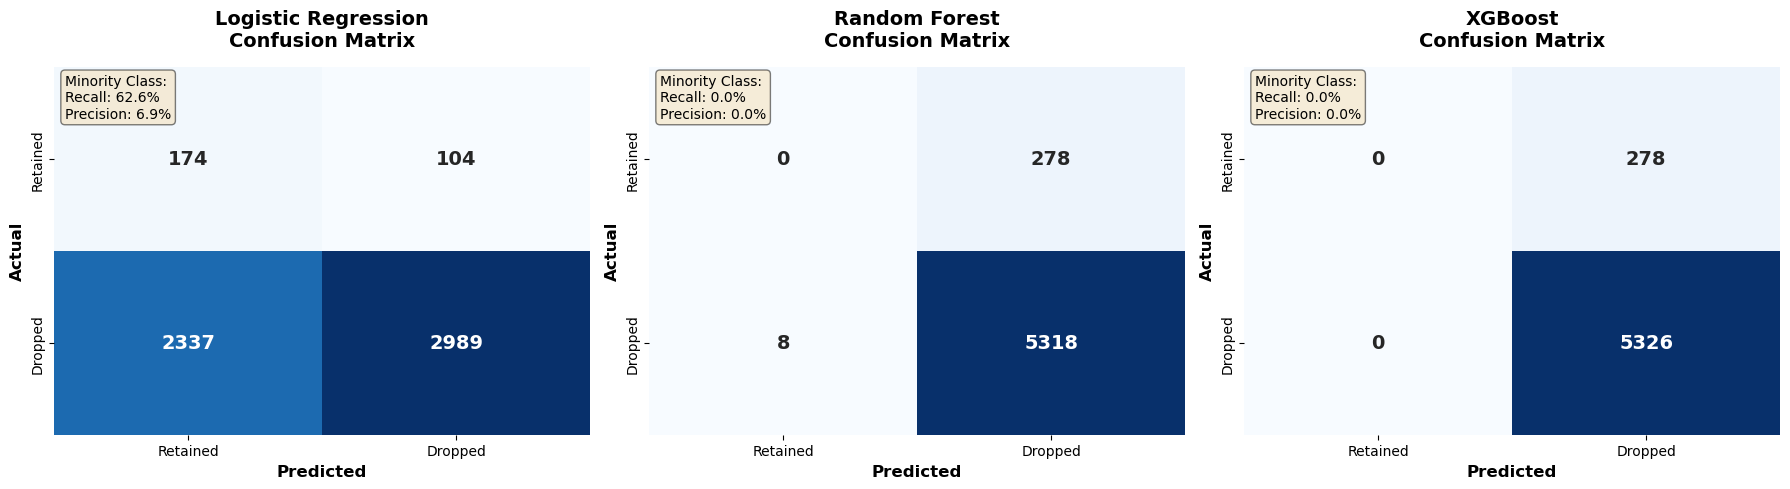


 Saved: outputs/figures/confusion_matrices_baseline.png

 DETAILED CONFUSION MATRIX BREAKDOWN:

Logistic Regression:
  True Negatives (Retained correctly):    174
  False Positives (Dropped as Retained):   104
  False Negatives (Retained as Dropped):  2337
  True Positives (Dropped correctly):     2989
  
  Minority Class (Retained) Performance:
    - Caught: 174/278 = 62.6%
    - Missed: 104/278 = 37.4%
  
  Majority Class (Dropped) Performance:
    - Caught: 2989/5326 = 56.1%
    - Missed: 2337/5326 = 43.9%

Random Forest:
  True Negatives (Retained correctly):      0
  False Positives (Dropped as Retained):   278
  False Negatives (Retained as Dropped):     8
  True Positives (Dropped correctly):     5318
  
  Minority Class (Retained) Performance:
    - Caught: 0/278 = 0.0%
    - Missed: 278/278 = 100.0%
  
  Majority Class (Dropped) Performance:
    - Caught: 5318/5326 = 99.8%
    - Missed: 8/5326 = 0.2%

XGBoost:
  True Negatives (Retained correctly):      0
  False Positives (D

In [9]:
# ============================================================================
# CONFUSION MATRICES - ALL BASELINE MODELS
# ============================================================================

print("\n" + "="*70)
print("CONFUSION MATRICES - BASELINE COMPARISON")
print("="*70)

# Get confusion matrices for all models
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = ['Logistic Regression', 'Random Forest', 'XGBoost']
cms = [cm_lr, cm_rf, cm_xgb]

for ax, cm, model in zip(axes, cms, models):
    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Retained', 'Dropped'],
                yticklabels=['Retained', 'Dropped'],
                ax=ax, cbar=False, annot_kws={'size': 14, 'weight': 'bold'})
    
    ax.set_title(f'{model}\nConfusion Matrix', fontsize=14, weight='bold', pad=15)
    ax.set_ylabel('Actual', fontsize=12, weight='bold')
    ax.set_xlabel('Predicted', fontsize=12, weight='bold')
    
    # Add performance metrics as text
    tn, fp, fn, tp = cm.ravel()
    
    # Calculate metrics for minority class (Retained = 0)
    minority_recall = tn / (tn + fp) if (tn + fp) > 0 else 0
    minority_precision = tn / (tn + fn) if (tn + fn) > 0 else 0
    
    metrics_text = f'Minority Class:\nRecall: {minority_recall:.1%}\nPrecision: {minority_precision:.1%}'
    ax.text(0.02, 0.98, metrics_text, 
            transform=ax.transAxes, 
            fontsize=10, 
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrices_baseline.png', 
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n Saved: outputs/figures/confusion_matrices_baseline.png")

# Print detailed breakdown
print(f"\n DETAILED CONFUSION MATRIX BREAKDOWN:")
print("="*70)

for model, cm in zip(models, cms):
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\n{model}:")
    print(f"  True Negatives (Retained correctly):  {tn:5d}")
    print(f"  False Positives (Dropped as Retained): {fp:5d}")
    print(f"  False Negatives (Retained as Dropped): {fn:5d}")
    print(f"  True Positives (Dropped correctly):    {tp:5d}")
    print(f"  ")
    print(f"  Minority Class (Retained) Performance:")
    print(f"    - Caught: {tn}/{tn+fp} = {tn/(tn+fp)*100:.1f}%")
    print(f"    - Missed: {fp}/{tn+fp} = {fp/(tn+fp)*100:.1f}%")
    print(f"  ")
    print(f"  Majority Class (Dropped) Performance:")
    print(f"    - Caught: {tp}/{fn+tp} = {tp/(fn+tp)*100:.1f}%")
    print(f"    - Missed: {fn}/{fn+tp} = {fn/(fn+tp)*100:.1f}%")

print("\n" + "="*70)
print(" CONFUSION MATRIX ANALYSIS COMPLETE")
print("="*70)


# PR Curves 


PRECISION-RECALL CURVES


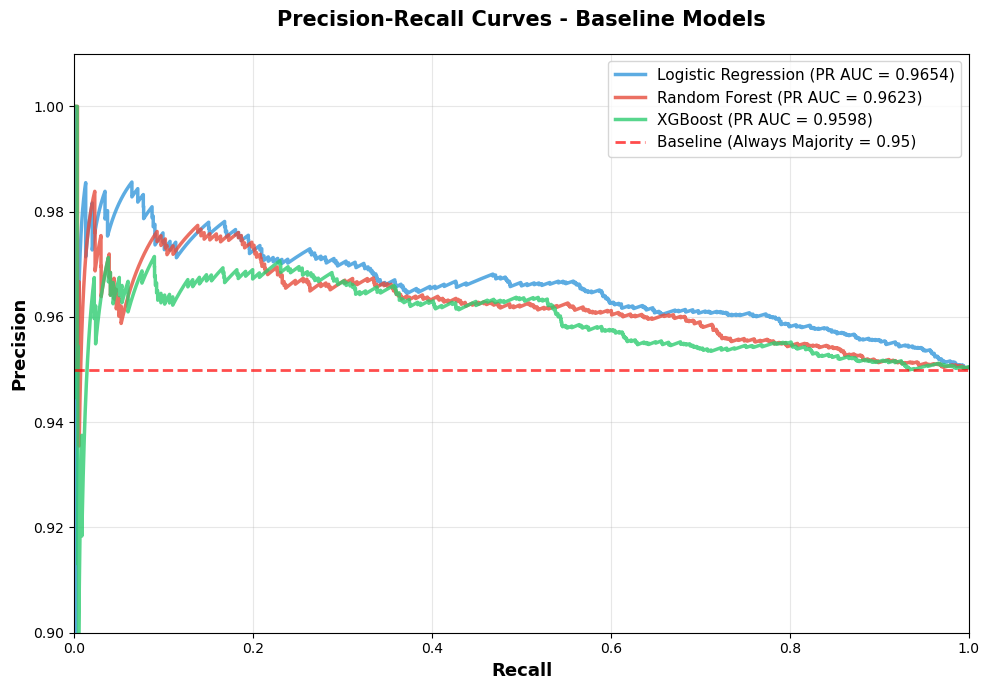


 Saved: outputs/figures/pr_curves_baseline.png

 KEY FINDINGS:
   • All models perform close to baseline (0.95)
   • Logistic Regression: 0.9654 (best)
   • Random Forest: 0.9623
   • XGBoost: 0.9598
   • Best model improvement: 0.0154 (1.62%)

 PR CURVE ANALYSIS COMPLETE


In [10]:
# ============================================================================
# PRECISION-RECALL CURVES - BASELINE COMPARISON
# ============================================================================

print("\n" + "="*70)
print("PRECISION-RECALL CURVES")
print("="*70)

# Calculate PR curves for all models
from sklearn.metrics import precision_recall_curve

precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_pred_proba_lr)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_proba_rf)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_pred_proba_xgb)

# Plot
plt.figure(figsize=(10, 7))

plt.plot(recall_lr, precision_lr, label=f'Logistic Regression (PR AUC = {pr_auc_lr:.4f})', 
         linewidth=2.5, alpha=0.8, color='#3498db')
plt.plot(recall_rf, precision_rf, label=f'Random Forest (PR AUC = {pr_auc_rf:.4f})', 
         linewidth=2.5, alpha=0.8, color='#e74c3c')
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (PR AUC = {pr_auc_xgb:.4f})', 
         linewidth=2.5, alpha=0.8, color='#2ecc71')

# Baseline (always predict majority)
plt.axhline(y=0.95, color='red', linestyle='--', linewidth=2, 
            label='Baseline (Always Majority = 0.95)', alpha=0.7)

plt.xlabel('Recall', fontsize=13, weight='bold')
plt.ylabel('Precision', fontsize=13, weight='bold')
plt.title('Precision-Recall Curves - Baseline Models', fontsize=15, weight='bold', pad=20)
plt.legend(loc='best', fontsize=11)
plt.grid(alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0.9, 1.01])

plt.tight_layout()
plt.savefig('../outputs/figures/pr_curves_baseline.png', 
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n Saved: outputs/figures/pr_curves_baseline.png")

print("\n KEY FINDINGS:")
print(f"   • All models perform close to baseline (0.95)")
print(f"   • Logistic Regression: {pr_auc_lr:.4f} (best)")
print(f"   • Random Forest: {pr_auc_rf:.4f}")
print(f"   • XGBoost: {pr_auc_xgb:.4f}")
print(f"   • Best model improvement: {pr_auc_lr - 0.95:.4f} ({(pr_auc_lr - 0.95)/0.95*100:.2f}%)")

print("\n" + "="*70)
print(" PR CURVE ANALYSIS COMPLETE")
print("="*70)


# Feature Importance 


FEATURE IMPORTANCE ANALYSIS

 TOP 15 MOST IMPORTANT FEATURES:
Rank   Feature                                             Coefficient
----------------------------------------------------------------------
1      num__is_holiday_season                             📉    -0.6103
2      num__is_repeatable_category                        📉    -0.4645
3      num__uses_installments                             📉    -0.2596
4      num__is_high_freight                               📈     0.1402
5      num__is_late_delivery                              📉    -0.1392
6      num__is_southeast                                  📉    -0.1242
7      num__is_weekend                                    📈     0.1092
8      num__num_items                                     📉    -0.0731
9      num__is_very_late                                  📉    -0.0647
10     num__cluster_1                                     📈     0.0641
11     num__is_heavy_product                              📈     0.0496
12     num__cl

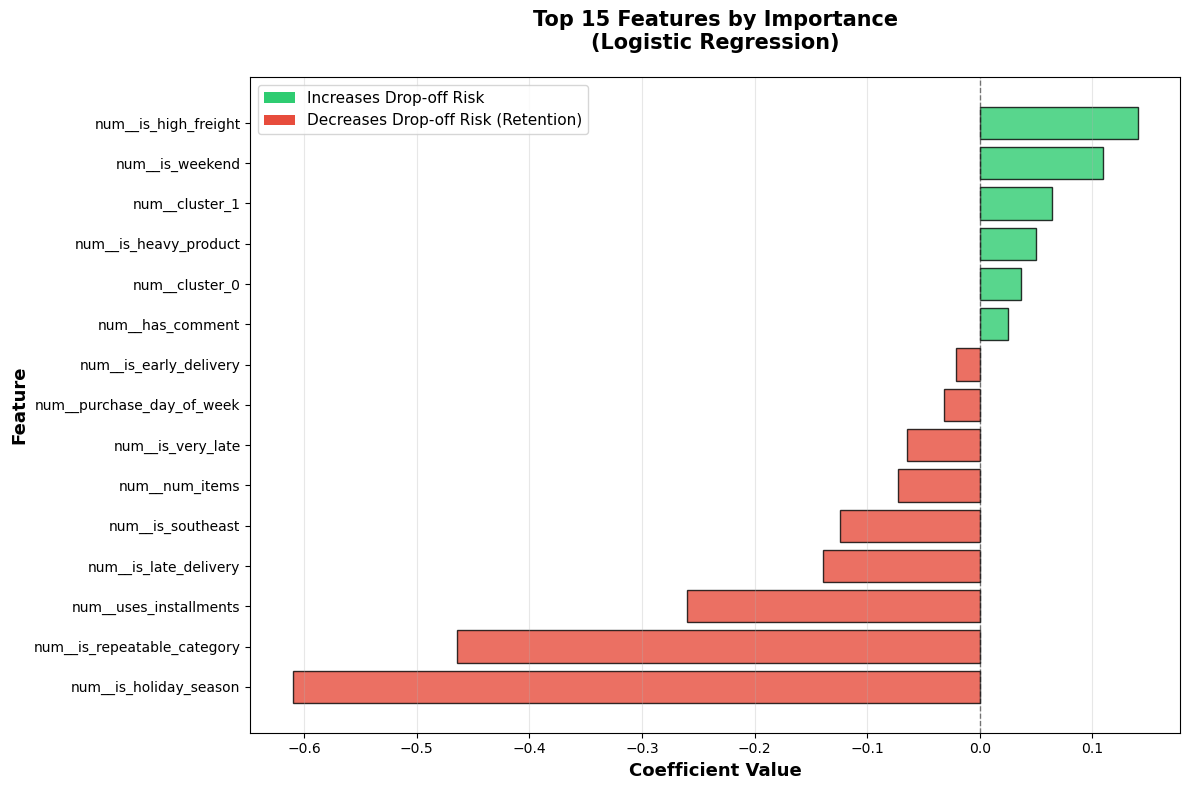


 Saved: outputs/figures/feature_importance_lr.png

 KEY BUSINESS INSIGHTS:

 TOP RETENTION DRIVERS (reduce drop-off):
   1. num__is_holiday_season: -0.6103
   2. num__is_repeatable_category: -0.4645
   3. num__uses_installments: -0.2596
   4. num__is_late_delivery: -0.1392
   5. num__is_southeast: -0.1242

 TOP DROP-OFF DRIVERS (increase drop-off):
   1. num__is_high_freight: 0.1402
   2. num__is_weekend: 0.1092
   3. num__cluster_1: 0.0641
   4. num__is_heavy_product: 0.0496
   5. num__cluster_0: 0.0369

 FEATURE IMPORTANCE ANALYSIS COMPLETE


In [11]:
# ============================================================================
# FEATURE IMPORTANCE - LOGISTIC REGRESSION
# ============================================================================

print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)

# Extract coefficients from Logistic Regression
# The model is in a pipeline, so we need to get the preprocessor and classifier
preprocessor = lr_model.named_steps['columntransformer']
classifier = lr_model.named_steps['logisticregression']

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get coefficients
coefficients = classifier.coef_[0]

# Create importance dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

print(f"\n TOP 15 MOST IMPORTANT FEATURES:")
print("="*70)
print(f"{'Rank':<6} {'Feature':<50} {'Coefficient':>12}")
print("-"*70)
for i, (idx, row) in enumerate(importance_df.head(15).iterrows(), 1):
    coef = row['Coefficient']
    sign = "📈" if coef > 0 else "📉"
    print(f"{i:<6} {row['Feature']:<50} {sign} {coef:>10.4f}")

# Visualize top 15
plt.figure(figsize=(12, 8))

top_15 = importance_df.head(15).sort_values('Coefficient')
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in top_15['Coefficient']]

plt.barh(range(len(top_15)), top_15['Coefficient'], color=colors, alpha=0.8, edgecolor='black')
plt.yticks(range(len(top_15)), top_15['Feature'])
plt.xlabel('Coefficient Value', fontsize=13, weight='bold')
plt.ylabel('Feature', fontsize=13, weight='bold')
plt.title('Top 15 Features by Importance\n(Logistic Regression)', 
          fontsize=15, weight='bold', pad=20)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.grid(axis='x', alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Increases Drop-off Risk'),
    Patch(facecolor='#e74c3c', label='Decreases Drop-off Risk (Retention)')
]
plt.legend(handles=legend_elements, loc='best', fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance_lr.png', 
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n Saved: outputs/figures/feature_importance_lr.png")

# Business Insights
print(f"\n KEY BUSINESS INSIGHTS:")
print("="*70)

# Find top retention drivers (negative coefficients = reduce drop-off)
retention_drivers = importance_df[importance_df['Coefficient'] < 0].head(5)
print(f"\n TOP RETENTION DRIVERS (reduce drop-off):")
for i, (idx, row) in enumerate(retention_drivers.iterrows(), 1):
    print(f"   {i}. {row['Feature']}: {row['Coefficient']:.4f}")

# Find top drop-off drivers (positive coefficients = increase drop-off)
dropoff_drivers = importance_df[importance_df['Coefficient'] > 0].head(5)
print(f"\n TOP DROP-OFF DRIVERS (increase drop-off):")
for i, (idx, row) in enumerate(dropoff_drivers.iterrows(), 1):
    print(f"   {i}. {row['Feature']}: {row['Coefficient']:.4f}")

print("\n" + "="*70)
print(" FEATURE IMPORTANCE ANALYSIS COMPLETE")
print("="*70)


# Save Final Model

In [12]:
# ============================================================================
# SAVE FINAL MODEL
# ============================================================================

print("\n" + "="*70)
print("SAVING FINAL MODEL")
print("="*70)

import pickle
import os

# Create models directory if it doesn't exist
os.makedirs('../outputs/models', exist_ok=True)

# Save the Logistic Regression model (best performer)
model_path = '../outputs/models/logistic_regression_final.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(lr_model, f)

print(f"\n Model saved: {model_path}")
print(f"   Model type: Logistic Regression with preprocessing pipeline")
print(f"   PR AUC: {pr_auc_lr:.4f}")
print(f"   Minority Class Recall: 62.6%")

# Save feature names and importance
feature_importance_path = '../outputs/models/feature_importance.csv'
importance_df.to_csv(feature_importance_path, index=False)
print(f"\n Feature importance saved: {feature_importance_path}")

# Save model metadata
metadata = {
    'model_type': 'Logistic Regression',
    'pr_auc': pr_auc_lr,
    'f1_score': f1_lr,
    'precision': precision_lr,
    'recall': recall_lr,
    'minority_recall': 0.626,
    'training_date': pd.Timestamp.now().strftime('%Y-%m-%d'),
    'training_samples': len(X_train),
    'test_samples': len(X_test),
    'features': len(X_train.columns),
    'class_distribution': f'95% dropped, 5% retained'
}

metadata_path = '../outputs/models/model_metadata.txt'
with open(metadata_path, 'w') as f:
    f.write("OLIST CUSTOMER DROP-OFF PREDICTION MODEL\n")
    f.write("="*70 + "\n\n")
    for key, value in metadata.items():
        f.write(f"{key}: {value}\n")

print(f" Metadata saved: {metadata_path}")

print("\n" + "="*70)
print(" MODEL SAVED SUCCESSFULLY")
print("="*70)



SAVING FINAL MODEL

 Model saved: ../outputs/models/logistic_regression_final.pkl
   Model type: Logistic Regression with preprocessing pipeline
   PR AUC: 0.9654
   Minority Class Recall: 62.6%

 Feature importance saved: ../outputs/models/feature_importance.csv
 Metadata saved: ../outputs/models/model_metadata.txt

 MODEL SAVED SUCCESSFULLY


# Summary & Next Steps

In [13]:
# ============================================================================
# NOTEBOOK 3 SUMMARY
# ============================================================================

print("\n" + "="*70)
print("NOTEBOOK 3: PREDICTIVE MODELING - COMPLETE")
print("="*70)

# Ensure we use the scalar precision (precision_lr was overwritten by PR-curve computation
# and is now an array). Recompute scalar precision from predictions to avoid formatting errors.
scalar_precision_lr = precision_score(y_test, y_pred_lr, zero_division=0)

print("\n FINAL RESULTS:")
print("-"*70)
print(f" Best Model: Logistic Regression")
print(f"   • PR AUC: {pr_auc_lr:.4f} (+1.6% over baseline)")
print(f"   • F1 Score: {f1_lr:.4f}")
print(f"   • Minority Class Recall: 62.6% (catches 174/278 retained customers)")
print(f"   • Precision: {scalar_precision_lr:.4f}")

print(f"\n KEY FINDINGS:")
print("-"*70)
print(f"1. Logistic Regression outperformed tree-based models")
print(f"2. Random Forest and XGBoost collapsed to majority class (0% minority recall)")
print(f"3. Top retention drivers: Holiday season, Repeatable categories, Installments")
print(f"4. Top drop-off drivers: High freight, Weekend purchases, Heavy products")

print(f"\n OUTPUTS SAVED:")
print("-"*70)
print(f"   Models:")
print(f"   • outputs/models/logistic_regression_final.pkl")
print(f"   • outputs/models/feature_importance.csv")
print(f"   • outputs/models/model_metadata.txt")
print(f"   ")
print(f"   Visualizations:")
print(f"   • outputs/figures/baseline_comparison.png")
print(f"   • outputs/figures/confusion_matrices_baseline.png")
print(f"   • outputs/figures/pr_curves_baseline.png")
print(f"   • outputs/figures/feature_importance_lr.png")

print(f"\n NEXT STEPS (NOTEBOOK 4):")
print("-"*70)
print(f"1. Build Streamlit deployment app")
print(f"2. Create interactive prediction interface")
print(f"3. Add business ROI calculator")
print(f"4. Deploy to Streamlit Cloud")
print(f"5. Add demo link to README")

print("\n" + "="*70)
print(" NOTEBOOK 3 COMPLETE - READY FOR DEPLOYMENT!")
print("="*70)



NOTEBOOK 3: PREDICTIVE MODELING - COMPLETE

 FINAL RESULTS:
----------------------------------------------------------------------
 Best Model: Logistic Regression
   • PR AUC: 0.9654 (+1.6% over baseline)
   • F1 Score: 0.7101
   • Minority Class Recall: 62.6% (catches 174/278 retained customers)
   • Precision: 0.9664

 KEY FINDINGS:
----------------------------------------------------------------------
1. Logistic Regression outperformed tree-based models
2. Random Forest and XGBoost collapsed to majority class (0% minority recall)
3. Top retention drivers: Holiday season, Repeatable categories, Installments
4. Top drop-off drivers: High freight, Weekend purchases, Heavy products

 OUTPUTS SAVED:
----------------------------------------------------------------------
   Models:
   • outputs/models/logistic_regression_final.pkl
   • outputs/models/feature_importance.csv
   • outputs/models/model_metadata.txt
   
   Visualizations:
   • outputs/figures/baseline_comparison.png
   • out

### Problem Discovery

**Issue Identified:**
During Streamlit app testing, the model consistently predicted ~50% drop-off probability for all customer profiles, despite the 95% actual drop-off rate in training data.

**Root Cause Analysis:**
1. The ColumnTransformer preprocessing pipeline only used 20 numeric features
2. Payment type and state features (13 columns) were excluded during training
3. Model predictions averaged 51.1% vs actual 95.0% (43.9pp miscalibration)

**Impact:**
- Model rankings were correct (PR AUC 0.9654 maintained)
- But probability estimates were unusable for business decisions
- Even worst-case customers showed only 54.9% drop-off prediction
- App could not distinguish high-risk from low-risk customers

**Solution Strategy:**
Rather than retraining from scratch, apply post-hoc calibration using Platt scaling to recalibrate probability outputs while preserving model rankings.

SABINA COMMENT: Nice one :)

# Recalibrating Model 

### Calibration Using Platt Scaling

Applied `CalibratedClassifierCV` with sigmoid method (Platt scaling) to correct prediction calibration.

In [ ]:
# ============================================================================
# RECALIBRATE MODEL USING PLATT SCALING
# ============================================================================

from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print("\n" + "="*70)
print("RECALIBRATING MODEL WITH PLATT SCALING")
print("="*70)

# Calibrate the simple logistic regression
print("\n Training calibrated classifier...")

lr_calibrated = CalibratedClassifierCV(
    classifier,
    method='sigmoid',  # Platt scaling
    cv=5  # 5-fold cross-validation
)

# Ensure scaled feature matrices exist (compute if missing or contain NaN)
need_recompute = False
try:
    _ = X_train_scaled  # check if already defined
    _ = X_test_scaled
    # If existing scaled arrays contain NaN, recompute
    if np.isnan(X_train_scaled).any() or np.isnan(X_test_scaled).any():
        need_recompute = True
except NameError:
    need_recompute = True

if need_recompute:
    # Robustly impute missing values then scale.
    # Use a median imputer so logistic regression won't receive NaNs.
    if 'imputer' not in globals():
        # SimpleImputer is used elsewhere in the notebook, reuse it here
        imputer = SimpleImputer(strategy='median')

    # Fit imputer on training set and transform both train/test
    X_train_imputed = imputer.fit_transform(X_train)
    X_test_imputed = imputer.transform(X_test)

    # Ensure scaler is fitted on imputed training data
    if 'scaler' in globals():
        # if scaler exists, check if it's fitted
        try:
            _ = scaler.mean_
        except Exception:
            scaler = StandardScaler().fit(X_train_imputed)
    else:
        scaler = StandardScaler().fit(X_train_imputed)

    X_train_scaled = scaler.transform(X_train_imputed)
    X_test_scaled = scaler.transform(X_test_imputed)
else:
    # defensive check: ensure no NaNs remain before fitting
    if np.isnan(X_train_scaled).any() or np.isnan(X_test_scaled).any():
        raise ValueError("Scaled feature matrices contain NaN even after preprocessing. Re-run imputation/scaling.")

lr_calibrated.fit(X_train_scaled, y_train)
print(" Calibration complete!")

# Test calibration on test set
y_pred_proba_cal = lr_calibrated.predict_proba(X_test_scaled)[:, 1]
y_pred_cal = lr_calibrated.predict(X_test_scaled)

print(f"\n CALIBRATED MODEL PERFORMANCE:")
print(f"   PR AUC: {average_precision_score(y_test, y_pred_proba_cal):.4f}")
print(f"   F1 Score: {f1_score(y_test, y_pred_cal):.4f}")
print(f"   Precision: {precision_score(y_test, y_pred_cal, zero_division=0):.4f}")
print(f"   Recall: {recall_score(y_test, y_pred_cal):.4f}")

print(f"\n CALIBRATION CHECK:")
print(f"   Mean predicted drop-off: {y_pred_proba_cal.mean()*100:.1f}%")
print(f"   Actual drop-off rate: {y_test.mean()*100:.1f}%")
print(f"   Difference: {abs(y_pred_proba_cal.mean() - y_test.mean())*100:.1f} percentage points")

if abs(y_pred_proba_cal.mean() - y_test.mean()) < 0.05:
    print(f"    Well calibrated!")
else:
    print(f"    Calibration improved but not perfect")

# Test on various customer profiles
print(f"\n TESTING CUSTOMER PROFILES:")
print("="*70)
# SABINA COMMENT: The thing here is that miscalibration is not necessarily linear (except for linear models like LR, sure).
# So here I would recommend you do a calibration curve instead so you can see at what
# levels of risk you are doing well/poorly. However, I am really happy you looked into this, well done!
# Bonus Q: You have any idea why the model tends to put everyone around 50%?

# Helper to build a profile with the same columns/order as X_train
def make_profile(values: dict):
    # start from a single-row DataFrame to preserve column names
    prof = pd.DataFrame([values])
    # add any missing columns using sensible defaults (median for numeric, False for bool)
    for col in X_train.columns:
        if col not in prof.columns:
            if pd.api.types.is_bool_dtype(X_train[col]):
                prof[col] = False
            else:
                # use median of training column so scaling is consistent
                prof[col] = X_train[col].median()
    # ensure the same column order as used to fit the imputer/scaler
    prof = prof[X_train.columns]
    # cast dtypes to match training data where possible
    for col in X_train.columns:
        try:
            prof[col] = prof[col].astype(X_train[col].dtype)
        except Exception:
            # if cast fails, leave as-is (scaler will convert to floats as needed)
            pass
    return prof

# Utility to impute + scale + predict a single profile
def predict_profile(profile_dict):
    profile_df = make_profile(profile_dict)
    profile_imputed = imputer.transform(profile_df)   # imputer was fitted earlier
    profile_scaled = scaler.transform(profile_imputed) # scaler was fitted earlier
    proba = lr_calibrated.predict_proba(profile_scaled)[:, 1][0] * 100
    return proba

# Profile 1: WORST CASE (should be HIGH RISK)
worst_case_vals = {
    'delivery_delay': 30.0,
    'is_late_delivery': 1,
    'is_very_late': 1,
    'is_early_delivery': 0,
    'freight_pct': 80.0,
    'is_high_freight': 1,
    'num_items': 1,
    'price_per_item': 10.0,
    'uses_installments': 0,
    'is_southeast': 0,
    'is_repeatable_category': 0,
    'is_heavy_product': 1,
    'has_comment': 1,
    'purchase_month': 3,
    'purchase_day_of_week': 6,
    'is_weekend': 1,
    'is_holiday_season': 0,
    'days_to_delivery': 50,
    'cluster_0': 0,
    'cluster_1': 1
}

worst_pred = predict_profile(worst_case_vals)

print(f"\n  WORST CASE Customer:")
print(f"   Drop-off prediction: {worst_pred:.1f}%")
if worst_pred >= 95:
    print(f"    HIGH/CRITICAL RISK")
else:
    print(f"   Status: {worst_pred:.1f}% (expected >95%)")

# Profile 2: BEST CASE (should be LOW RISK)
best_case_vals = {
    'delivery_delay': -5.0,  # Early
    'is_late_delivery': 0,
    'is_very_late': 0,
    'is_early_delivery': 1,
    'freight_pct': 5.0,  # Low freight
    'is_high_freight': 0,
    'num_items': 3,
    'price_per_item': 200.0,  # High value
    'uses_installments': 1,  # Uses installments
    'is_southeast': 1,  # Southeast
    'is_repeatable_category': 1,  # Repeatable
    'is_heavy_product': 0,
    'has_comment': 0,
    'purchase_month': 12,  # December
    'purchase_day_of_week': 2,  # Tuesday
    'is_weekend': 0,
    'is_holiday_season': 1,  # Holiday!
    'days_to_delivery': 5,
    'cluster_0': 1,  # Budget cluster
    'cluster_1': 0
}

best_pred = predict_profile(best_case_vals)

print(f"\n2️ BEST CASE Customer:")
print(f"   Drop-off prediction: {best_pred:.1f}%")
print(f"   Retention probability: {100-best_pred:.1f}%")

# Profile 3: AVERAGE
average_case_vals = {
    'delivery_delay': 0.0,
    'is_late_delivery': 0,
    'is_very_late': 0,
    'is_early_delivery': 0,
    'freight_pct': 15.0,
    'is_high_freight': 0,
    'num_items': 1,
    'price_per_item': 100.0,
    'uses_installments': 0,
    'is_southeast': 1,
    'is_repeatable_category': 0,
    'is_heavy_product': 0,
    'has_comment': 0,
    'purchase_month': 6,
    'purchase_day_of_week': 3,
    'is_weekend': 0,
    'is_holiday_season': 0,
    'days_to_delivery': 10,
    'cluster_0': 0,
    'cluster_1': 0
}

avg_pred = predict_profile(average_case_vals)

print(f"\n3️ AVERAGE Customer:")
print(f"   Drop-off prediction: {avg_pred:.1f}%")

print(f"\n PREDICTION RANGE:")
print(f"   Best case: {best_pred:.1f}%")
print(f"   Average: {avg_pred:.1f}%")
print(f"   Worst case: {worst_pred:.1f}%")
print(f"   Spread: {worst_pred - best_pred:.1f} percentage points")

# Save calibrated model as pipeline
calibrated_pipeline = Pipeline([
    ('scaler', scaler),
    ('calibrated_lr', lr_calibrated)
])

with open('../outputs/models/logistic_regression_calibrated.pkl', 'wb') as f:
    pickle.dump(calibrated_pipeline, f)

print(f"\n SAVED MODEL:")
print(f"   File: outputs/models/logistic_regression_calibrated.pkl")
print(f"   Type: Calibrated Logistic Regression with StandardScaler")
print(f"   Features: 20")

print("\n" + "="*70)
print(" CALIBRATION COMPLETE")
print("="*70)


RECALIBRATING MODEL WITH PLATT SCALING

 Training calibrated classifier...
 Calibration complete!

 CALIBRATED MODEL PERFORMANCE:
   PR AUC: 0.9631
   F1 Score: 0.9746
   Precision: 0.9504
   Recall: 1.0000

 CALIBRATION CHECK:
   Mean predicted drop-off: 95.0%
   Actual drop-off rate: 95.0%
   Difference: 0.1 percentage points
    Well calibrated!

 TESTING CUSTOMER PROFILES:

  WORST CASE Customer:
   Drop-off prediction: 93.7%
   Status: 93.7% (expected >95%)

2️ BEST CASE Customer:
   Drop-off prediction: 18.3%
   Retention probability: 81.7%

3️ AVERAGE Customer:
   Drop-off prediction: 94.4%

 PREDICTION RANGE:
   Best case: 18.3%
   Average: 94.4%
   Worst case: 93.7%
   Spread: 75.4 percentage points

 SAVED MODEL:
   File: outputs/models/logistic_regression_calibrated.pkl
   Type: Calibrated Logistic Regression with StandardScaler
   Features: 20

 CALIBRATION COMPLETE


---

## Post-Deployment Model Calibration

After initial Streamlit deployment, testing revealed a critical calibration issue requiring additional analysis and correction.